## написала свою нейросетку для определения данных с шумом точек, принадлежащих функции 2**x * torch.sin(2**-x)

#### ошибка получилась 0.024201426655054092

In [1]:
import torch

def target_function(x):
    return 2**x * torch.sin(2**-x)

class RegressionNet(torch.nn.Module):
    def __init__(self, n_neurons):
        super(RegressionNet, self).__init__()
        self.lr1 = torch.nn.Linear(1, n_neurons)
        self.act1 = torch.nn.Tanh()
        self.lr2 = torch.nn.Linear(n_neurons, n_neurons)
        self.act2 = torch.nn.Tanh()
        self.lr3 = torch.nn.Linear(n_neurons, 1)

    def forward(self, x):
        x = self.lr1(x)
        x = self.act1(x)
        x = self.lr2(x)
        x = self.act2(x)
        x = self.lr3(x)
        return x

net = RegressionNet(10)

# ------Dataset preparation start--------:
x_train =  torch.linspace(-10, 5, 100)
y_train = target_function(x_train)
noise = torch.randn(y_train.shape) / 20.
y_train = y_train + noise
x_train.unsqueeze_(1)
y_train.unsqueeze_(1)

x_validation = torch.linspace(-10, 5, 100)
y_validation = target_function(x_validation)
x_validation.unsqueeze_(1)
y_validation.unsqueeze_(1)
# ------Dataset preparation end--------:


optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

def loss(pred, target):
    func = torch.abs(pred - target)
    return func.mean()

for epoch_index in range(400):
    optimizer.zero_grad()

    y_pred = net.forward(x_train)
    loss_value = loss(y_pred, y_train)
    loss_value.backward()
    optimizer.step()

# Проверка осуществляется вызовом кода:
print(loss(net.forward(x_validation), y_validation).item())
# (раскомментируйте, если решаете задание локально)

0.029208803549408913


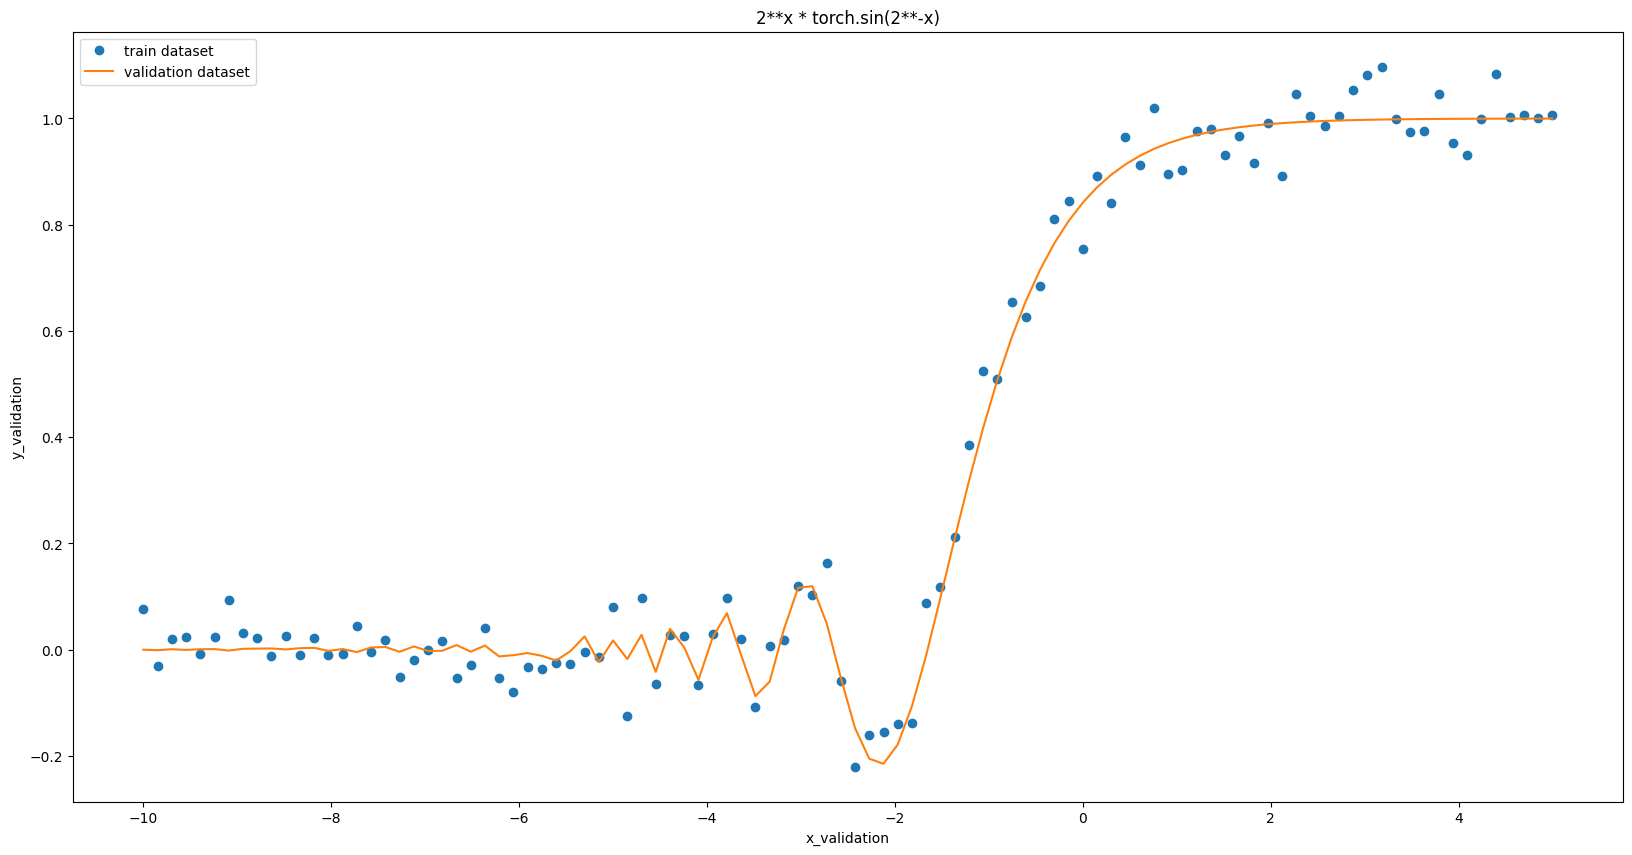

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (20 , 10)

# Визуализация подготовленных данных
plt.plot(x_train.numpy(), y_train.numpy(), 'o', label='train dataset')
# Визуализация тестовых данных
plt.plot(x_validation.numpy(), y_validation.numpy(), '-', label='validation dataset')
# Визуализация валидационных данных
plt.title('2**x * torch.sin(2**-x)')
plt.legend(loc='upper left')
plt.xlabel('x_validation')
plt.ylabel('y_validation')
plt.show()

In [3]:
train_losses = []
val_losses = []

for epoch_index in range(500):
    # Обучение
    optimizer.zero_grad()
    y_pred = net(x_train)
    loss_value = loss(y_pred, y_train)
    loss_value.backward()
    optimizer.step()
    
    # Сохраняем ошибки
    train_losses.append(loss_value.item())
    
    # Ошибка на валидации (без градиентов)
    with torch.no_grad():
        val_pred = net(x_validation)
        val_loss = loss(val_pred, y_validation)
        val_losses.append(val_loss.item())
    
    # Печатаем каждые 50 эпох
    if epoch_index % 50 == 0:
        print(f"Epoch {epoch_index}, Train loss: {loss_value:.4f}, Val loss: {val_loss:.4f}")

# После обучения посмотрим итог
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

Epoch 0, Train loss: 0.0523, Val loss: 0.0294
Epoch 50, Train loss: 0.0519, Val loss: 0.0290
Epoch 100, Train loss: 0.0515, Val loss: 0.0290
Epoch 150, Train loss: 0.0512, Val loss: 0.0289
Epoch 200, Train loss: 0.0509, Val loss: 0.0288
Epoch 250, Train loss: 0.0507, Val loss: 0.0285
Epoch 300, Train loss: 0.0503, Val loss: 0.0287
Epoch 350, Train loss: 0.0501, Val loss: 0.0285
Epoch 400, Train loss: 0.0497, Val loss: 0.0283
Epoch 450, Train loss: 0.0495, Val loss: 0.0281
Final train loss: 0.0492
Final val loss: 0.0280


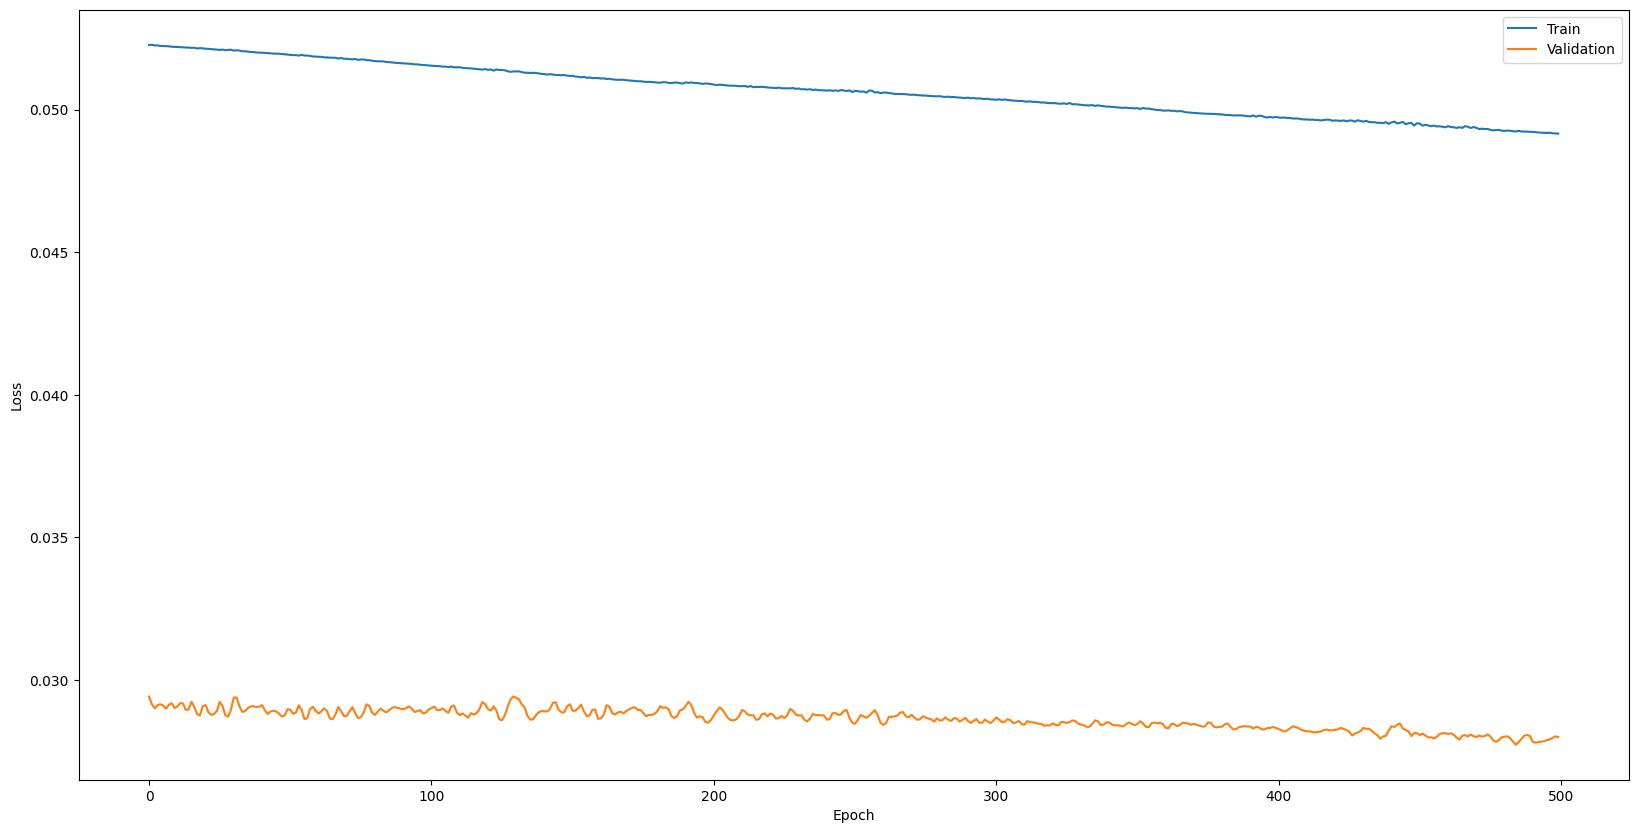

In [4]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [7]:
def metric(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

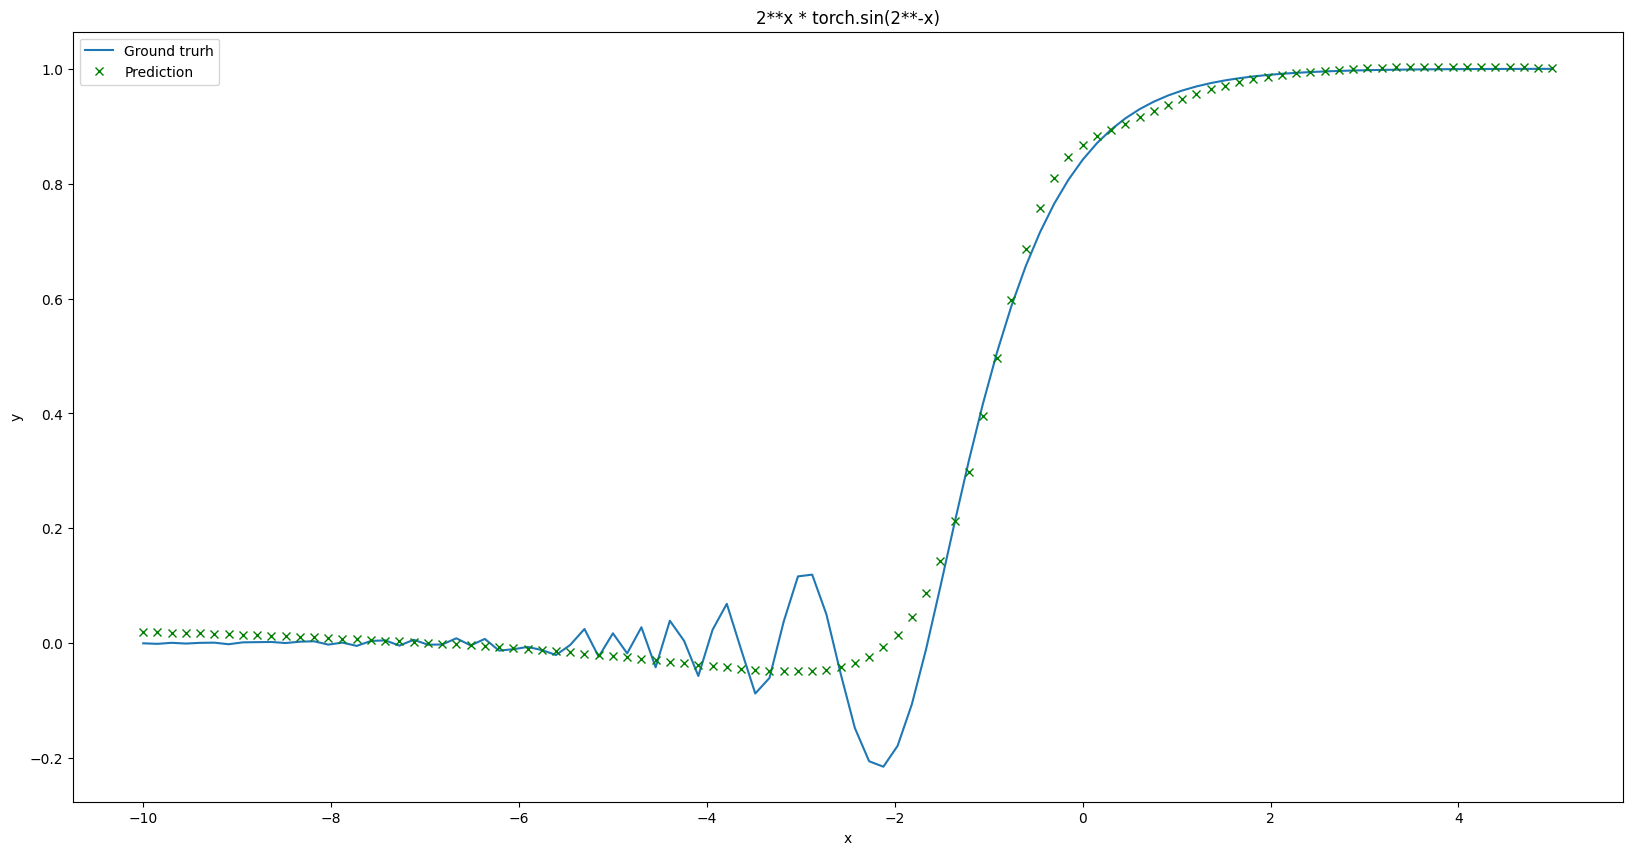

0.0028048031963407993


In [8]:
def predict(net, x, y):
  y_pred = net.forward(x)
  
  # Визуализация тестовых данных
  plt.plot(x.numpy(), y.numpy(), '-', label='Ground trurh')                     
  # Визуализация предсказания нейросети данных
  plt.plot(x.numpy(), y_pred.data.numpy(), 'x', c='g', label='Prediction')      
  plt.title('2**x * torch.sin(2**-x)')
  plt.legend(loc='upper left')
  plt.xlabel('x')
  plt.ylabel('y')                                                             
  plt.show()

# Визуализация работы нейросети
predict(net, x_validation, y_validation)

# Проверка качества нейросети (погрешность)
print(metric(net.forward(x_validation), y_validation).item())

In [11]:
# Сохранение
torch.save(net, 'model.pth')

# Загрузка с отключенной безопасной загрузкой
model = torch.load('model.pth', weights_only=False)
model.eval()

RegressionNet(
  (lr1): Linear(in_features=1, out_features=10, bias=True)
  (act1): Tanh()
  (lr2): Linear(in_features=10, out_features=10, bias=True)
  (act2): Tanh()
  (lr3): Linear(in_features=10, out_features=1, bias=True)
)

## след степ

In [72]:
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [62]:
import sklearn.datasets
wine = sklearn.datasets.load_wine()

In [63]:
import pandas as pd
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

<class 'numpy.ndarray'>


In [70]:
df.nunique()

alcohol                         126
malic_acid                      133
ash                              79
alcalinity_of_ash                63
magnesium                        53
total_phenols                    97
flavanoids                      132
nonflavanoid_phenols             39
proanthocyanins                 101
color_intensity                 132
hue                              78
od280/od315_of_diluted_wines    122
proline                         121
target                            3
dtype: int64

In [87]:
from sklearn.model_selection import train_test_split

In [90]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=40)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [156]:
class WineNet(torch.nn.Module):
    def __init__(self, n_input, n_hidden_neurons):
        super(WineNet, self).__init__()
        self.lr1 = torch.nn.Linear(n_input, n_hidden_neurons)
        self.act1 = torch.nn.Sigmoid()
        self.lr2 = torch.nn.Linear(n_hidden_neurons, n_hidden_neurons)
        self.act2 = torch.nn.Sigmoid()
        self.lr3 = torch.nn.Linear(n_hidden_neurons, 3)
        self.sm = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.lr1(x)
        x = self.act1(x)
        x = self.lr2(x)
        x = self.act2(x)
        x = self.lr3(x)
        return x

    def inference(self, x):
        x = self.forward(x)
        x = self.sm(x)
        return x

n_input = 13
n_hidden_neurons = 20
loss = torch.nn.CrossEntropyLoss()
wine_net = WineNet(n_input, n_hidden_neurons)
optimizer = torch.optim.Adam(wine_net.parameters(), lr=0.003)

In [157]:
batch_size = 50

train_acc_history = []
test_acc_history = []

for epoch in range(1000):
    order = np.random.permutation(len(X_train))
    for x in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_ind = order[x:x+batch_size]

        x_batch = X_train[batch_ind]
        y_batch = y_train[batch_ind]

        preds = wine_net.forward(x_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()
        optimizer.step()

    if epoch % 10 == 0:
        test_logits = wine_net.forward(X_test)
        test_preds = test_logits.argmax(dim=1)
        test_acc = (test_preds == y_test).float().mean()
        test_acc_history.append(test_acc.item())
        
        train_logits = wine_net.forward(X_train)
        train_preds = train_logits.argmax(dim=1)
        train_acc = (train_preds == y_train).float().mean()
        train_acc_history.append(train_acc.item())

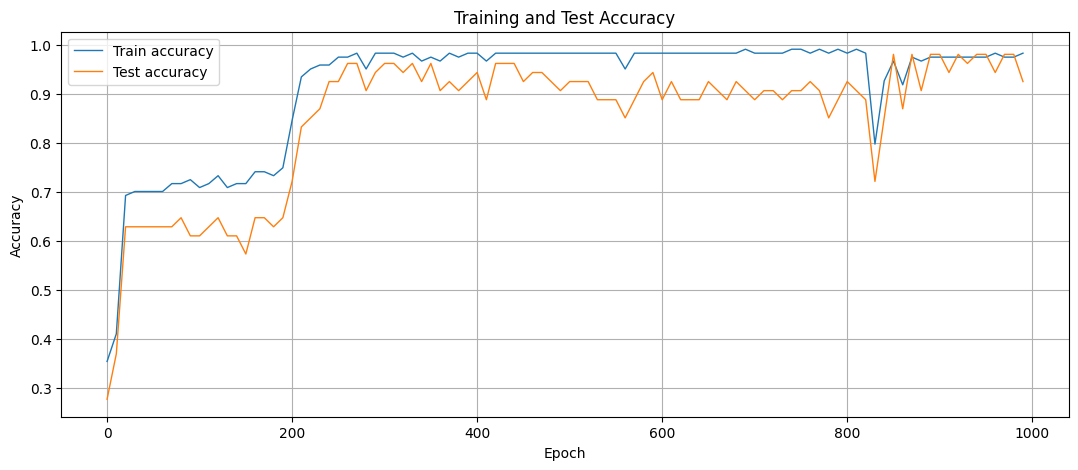

In [162]:
plt.figure(figsize=(13, 5))
plt.plot(range(0, 1000, 10), train_acc_history, label='Train accuracy', linewidth=1)
plt.plot(range(0, 1000, 10), test_acc_history, label='Test accuracy', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [159]:
print(wine_net.lr1.in_features, np.asarray((test_preds == y_test).float().mean()) > 0.8)

13 True


In [163]:
!nvidia-smi

zsh:1: command not found: nvidia-smi
